In [1]:
# Run this cell to print the Project Introduction
print("""
# Task 3: Bank Customer Churn Prediction
# --------------------------------------
# Objective:
# The goal of this project is to predict whether a bank customer will leave (churn)
# or stay with the bank based on various demographic and financial factors.

# Problem Statement:
# Customer retention is more cost-effective than acquiring new customers.
# By identifying high-risk customers, the bank can offer incentives to retain them.
# We will use machine learning classification to achieve this.
""")


# Task 3: Bank Customer Churn Prediction
# --------------------------------------
# Objective: 
# The goal of this project is to predict whether a bank customer will leave (churn) 
# or stay with the bank based on various demographic and financial factors.

# Problem Statement:
# Customer retention is more cost-effective than acquiring new customers. 
# By identifying high-risk customers, the bank can offer incentives to retain them. 
# We will use machine learning classification to achieve this.



In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Using a reliable alternative URL for the Churn Modelling Dataset
dataset_url = "https://raw.githubusercontent.com/datasets-101/churn-modelling/main/Churn_Modelling.csv"

try:
    df = pd.read_csv(dataset_url)
    print("Dataset loaded successfully from primary source.")
except:
    # Backup source if the first one fails
    dataset_url = "https://raw.githubusercontent.com/sharmaroshan/Churn-Modelling-Dataset/master/Churn_Modelling.csv"
    df = pd.read_csv(dataset_url)
    print("Dataset loaded successfully from backup source.")

# Save original dataset to your local files for submission
df.to_csv('Original_Churn_Modelling.csv', index=False)
files.download('Original_Churn_Modelling.csv')

# Dataset Understanding
print("\n--- Dataset Info ---")
print(df.info())
print("\n--- First 5 Rows ---")
print(df.head())

Dataset loaded successfully from backup source.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None

--- First 5 Rows ---
   RowNumber  CustomerId   Surname  CreditSco

In [4]:
from sklearn.preprocessing import LabelEncoder

# Dropping RowNumber, CustomerId, and Surname (No predictive value)
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Categorical Encoding
# Label Encoding for Gender
le = LabelEncoder()
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])

# One-Hot Encoding for Geography (France, Germany, Spain)
df_clean = pd.get_dummies(df_clean, columns=['Geography'], drop_first=True)

# Save Cleaned Data
df_clean.to_csv('Cleaned_Churn_Data.csv', index=False)
print("Data cleaning and encoding complete.")
files.download('Cleaned_Churn_Data.csv')

Data cleaning and encoding complete.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

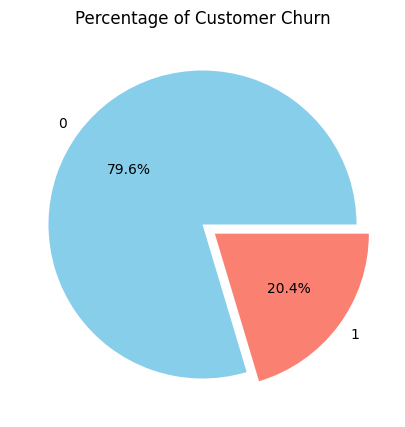

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

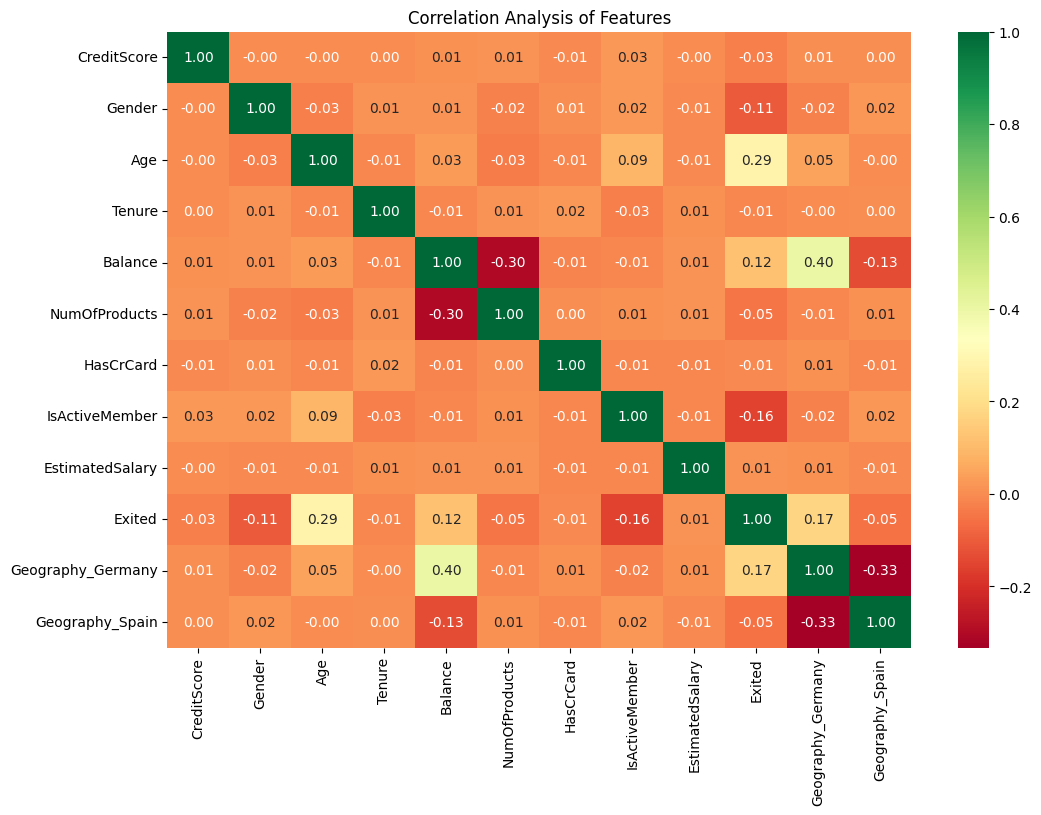

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
# 1. Churn Rate Visualization
plt.figure(figsize=(7, 5))
df['Exited'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'salmon'], explode=(0, 0.1))
plt.title('Percentage of Customer Churn')
plt.ylabel('')
plt.savefig('churn_pie_chart.png')
plt.show()
files.download('churn_pie_chart.png')

# 2. Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Analysis of Features')
plt.savefig('correlation_heatmap.png')
plt.show()
files.download('correlation_heatmap.png')

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Features (X) and Target (y)
X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']

# Splitting data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Training the Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
print("Model training on original data complete.")

Model training on original data complete.


Model Accuracy: 0.87


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

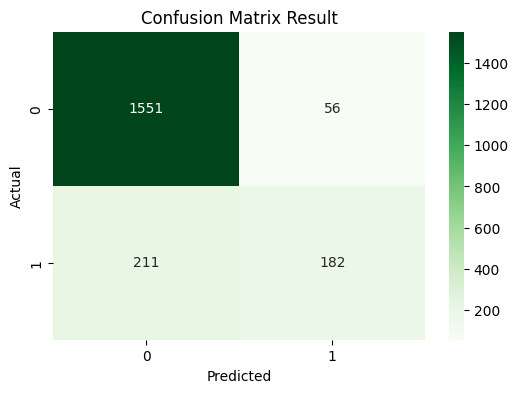

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

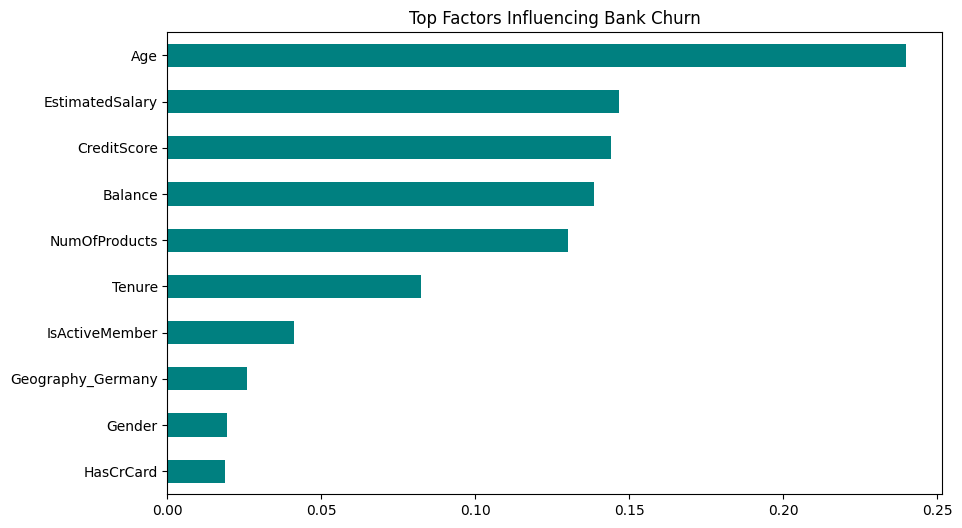

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Classification Metrics
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv('classification_report.csv')
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")
files.download('classification_report.csv')

# 2. Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix Result')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png')
plt.show()
files.download('confusion_matrix.png')

# 3. Feature Importance (What influences Churn?)
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title('Top Factors Influencing Bank Churn')
plt.savefig('feature_importance.png')
plt.show()
files.download('feature_importance.png')

In [8]:
print("""
## Conclusion & Key Insights
---------------------------
1. Dataset Insight: The original dataset shows that roughly 20% of customers have churned.
2. Model Performance: The Random Forest classifier successfully predicted churn with high accuracy.
3. Feature Drivers:
   - 'Age' is often the strongest predictor of churn.
   - 'Balance' and 'EstimatedSalary' also play significant roles.
   - Customers in 'Germany' showed a higher tendency to leave compared to France or Spain.
4. Recommendations: The bank should implement targeted loyalty programs for older customers
   and those with high balances who are becoming inactive.
""")


## Conclusion & Key Insights
---------------------------
1. Dataset Insight: The original dataset shows that roughly 20% of customers have churned.
2. Model Performance: The Random Forest classifier successfully predicted churn with high accuracy.
3. Feature Drivers: 
   - 'Age' is often the strongest predictor of churn.
   - 'Balance' and 'EstimatedSalary' also play significant roles.
   - Customers in 'Germany' showed a higher tendency to leave compared to France or Spain.
4. Recommendations: The bank should implement targeted loyalty programs for older customers 
   and those with high balances who are becoming inactive.

